### 加载数据

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skfolio import Population,MultiPeriodPortfolio
from skfolio import RiskMeasure, PerfMeasure, RatioMeasure
from skfolio.datasets import load_sp500_dataset
from skfolio.preprocessing import prices_to_returns
from ml4t.data.providers.qmt_provider import QmtProvider
from sklearn import set_config
from log_result import init_logger, log_result, log_print
from synthetic_returns import estimate_marginal_stats, synthesize_returns
set_config(transform_output="pandas")
init_logger("Synthetic_252")      # 只调用一次, 绑定文件名
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False   # 关键: 负号才不会变方块

[log] 已绑定: D:\machine-learning-for-trading\case_studies\lazy_trading\logs\Synthetic_252.log


In [2]:
# 加载数据
prices = pl.read_parquet("hs_funds_prices.parquet").to_pandas()
prices = prices.set_index('timestamp')
prices = prices.ffill()
prices = prices[prices.index.year > 2015]
all_symbols = prices.columns
print(f"资产池: {len(all_symbols)} 只 | {len(prices)} 天 | {prices.index[0].date()} ~ {prices.index[-1].date()}")

# 市场基准（从资产池中取出）
bench_symbol = "510300.SH"
bench = prices[bench_symbol]
prices = prices.drop(columns=[bench_symbol])

# 双口径收益率: X=绝对收益, X_net=超额收益(减基准), 筛选与训练统一用X_net
X = prices_to_returns(prices, drop_inceptions_nan=False)
bench_ret = prices_to_returns(bench.to_frame("bench"), drop_inceptions_nan=False)["bench"]
X_net = X.sub(bench_ret, axis=0)

# Inf 检查（两口径分别报告）
for label, df in [("X", X), ("X_net", X_net)]:
    inf = df.columns[np.isinf(df).any(axis=0)]
    print(f"{label} Inf列 {len(inf)}" + (f" -> {inf.tolist()}" if len(inf) else ""))

# 异常收益检查: 以超额口径判定, 同步剔除, 保证两口径列集一致
bad = X_net.columns[(X_net.abs() > 0.25).any()]
X = X.drop(columns=bad)
X_net = X_net.drop(columns=bad)
msg = f"异常剔除(±25%): {len(bad)} 列 -> {bad.tolist()}" if len(bad) else "异常剔除(±25%): 0 列"
print(msg)
print(f"清洗后: {X.shape[0]} 天 x {X.shape[1]} 资产 | 列集一致: {list(X.columns) == list(X_net.columns)}")

资产池: 2141 只 | 2604 天 | 2016-01-04 ~ 2026-09-18
X Inf列 0
X_net Inf列 0
异常剔除(±25%): 3 列 -> ['161811.SZ', '510030.SH', '511580.SH']
清洗后: 2603 天 x 2137 资产 | 列集一致: True


In [3]:
#stats  = estimate_marginal_stats(X)                        # ① 逐标的统计属性 + 拟合参数表
#X_fake = synthesize_returns(X, random_state=42)            # ② 默认 student_t + 保留截面相关
#X_fake, report = synthesize_returns(X, random_state=42, return_report=True)
X_ctrl = synthesize_returns(X, distribution="gaussian")    # 高斯对照项
X_fake = synthesize_returns(X, random_state=42)

硬截断告警：3 列截断比例超过阈值（最高 512420.SH: 截断 16.67% / 阈值 19.35% / 样本 30）
硬截断告警：1 列截断比例超过阈值（最高 520740.SH: 截断 10.34% / 阈值 20.00% / 样本 29）


### 参数搜索
- Walkforward:
    - CombinatorialPurgedCV

In [4]:
from wf_cpcv_search import load_nested_config
from cpcv_search_base import build_pipeline_src
from walkforward_parameter_search import compute_grid_size
from wf_cpcv_search import nested_adaptive_search, adaptive_multi_paths, build_test_parts, summarize_fold_params,summarize_top_k_params
from cpcv_analysis import discrete_lhs_safe, diagnose_oos_lhs, report_ann_distribution, turnover_series
from cpcv_analysis import plot_oos_vs_bench,excess_vs_bench, plot_paths_curve
from wf_cpcv_robustness import (perturbation_mc, sensitivity_curves, sensitivity_heatmap, topk_paths_eval,)
from wf_cpcv_ablation import ablate

In [5]:
log_print("mean(Annualized Sharpe Ratio)/2 - mean(MAXDD) + mean(SKEW)", section='Ojective', echo=False)
log_print(build_pipeline_src(), section="Model Pipeline", echo=False)

In [6]:
search_space = {'nondomin__min_n_assets': {'low': 5, 'high': 55, 'step': 5},
 'nondomin__threshold': {'low': -0.5, 'high': -0.3, 'step': 0.1},
 'correlate__threshold': {'low': 0.1, 'high': 0.5, 'step': 0.1},
 'extremes__k': {'low': 0.1, 'high': 0.6, 'step': 0.1},
 'nondomin__fitness_measures': [
    "mean-variance-kurt",
    "mean-variance-maxdd-kurt",
    "mean-variance-avgdd-kurt",
    "mean-semideviation-avgdd",
    "mean-mad-maxdd-kurt",
    "mean-mad-avgdd-kurt",
    "mean-mad-maxdd-cvar-kurt",
    "mean-mad-maxdd-cvar-sharpe",
    "mean-mad-avgdd-cvar-kurt",
    "mean-mad-avgdd-cvar-sharpe",
    ],
 'train_size': {'low': 252, 'high': 756, 'step': 126}}  # inner train size
log_print(search_space, section='Parameter Space', echo=False)
compute_grid_size(search_space)

49500

In [7]:
search_params = {'test_size': 252,
  'train_size': 756+252,
  'n_test_folds': 2,
  'n_jobs': 4,
  'cv_n_jobs': 10,
  'n_trials': 2000,
  'patience': 100,
  'sampler': 'tpe',
  'min_delta': 0.0001,
  'outer_purged_size': 0,
  'outer_reduce_test': False,
  'seed': 42,
  'verbose': True}
log_print(search_params, section="Search Parameter", echo=False)

In [8]:
# 386177
#X = X.tail(search_params['train_size'] + search_params['test_size'] + 1).copy()
fold_real = nested_adaptive_search(X,space=search_space, **search_params)

  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 0: mean score=0.8691 | test_ann=0.0381 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 1: mean score=0.7748 | test_ann=0.0727 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

...

Fold 3: mean score=0.6221 | test_ann=0.0979 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 4: mean score=0.8024 | test_ann=0.0874 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 5: mean score=0.3690 | test_ann=0.2453 | test_days=252


In [21]:
fold_fake = nested_adaptive_search(X_fake,space=search_space, **search_params)

  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 0: mean score=0.8889 | test_ann=0.1035 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 1: mean score=0.9878 | test_ann=-0.0073 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

...

Fold 3: mean score=0.7169 | test_ann=0.0219 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 4: mean score=0.5618 | test_ann=0.0593 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 5: mean score=0.5095 | test_ann=0.0312 | test_days=252


In [22]:
fold_ctrl = nested_adaptive_search(X_ctrl,space=search_space, **search_params)

  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 0: mean score=0.8772 | test_ann=0.0280 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 1: mean score=1.0711 | test_ann=-0.0160 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

...

Fold 3: mean score=0.7808 | test_ann=0.0578 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 4: mean score=1.0359 | test_ann=0.0566 | test_days=252


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 5: mean score=0.9761 | test_ann=0.0628 | test_days=252


#### Train vs Test

In [ ]:
train_population = Population([result['train'] for result in fold_real])
test_population = Population([result['test'] for result in fold_real])
train_population.set_portfolio_params(tag="Train")
test_population.set_portfolio_params(tag="Test")
population = train_population + test_population
population.plot_measures(
    x=RiskMeasure.ANNUALIZED_STANDARD_DEVIATION,
    y=PerfMeasure.ANNUALIZED_MEAN,
    color_scale=RatioMeasure.ANNUALIZED_SHARPE_RATIO,
    hover_measures=[RiskMeasure.MAX_DRAWDOWN, RatioMeasure.ANNUALIZED_SORTINO_RATIO],
)

In [23]:
train_population = Population([result['train'] for result in fold_fake])
test_population = Population([result['test'] for result in fold_fake])
train_population.set_portfolio_params(tag="Train")
test_population.set_portfolio_params(tag="Test")
population = train_population + test_population
population.plot_measures(
    x=RiskMeasure.ANNUALIZED_STANDARD_DEVIATION,
    y=PerfMeasure.ANNUALIZED_MEAN,
    color_scale=RatioMeasure.ANNUALIZED_SHARPE_RATIO,
    hover_measures=[RiskMeasure.MAX_DRAWDOWN, RatioMeasure.ANNUALIZED_SORTINO_RATIO],
)

In [24]:
train_population = Population([result['train'] for result in fold_ctrl])
test_population = Population([result['test'] for result in fold_ctrl])
train_population.set_portfolio_params(tag="Train")
test_population.set_portfolio_params(tag="Test")
population = train_population + test_population
population.plot_measures(
    x=RiskMeasure.ANNUALIZED_STANDARD_DEVIATION,
    y=PerfMeasure.ANNUALIZED_MEAN,
    color_scale=RatioMeasure.ANNUALIZED_SHARPE_RATIO,
    hover_measures=[RiskMeasure.MAX_DRAWDOWN, RatioMeasure.ANNUALIZED_SORTINO_RATIO],
)

### Step 1 | IS 审计：每折 P Luck + Top-K 候选
- dsr = 该折最优分数超过"纯运气挑最优"基准的经验概率（H0 噪声 MC deflate，N = 参数去重后的真实试验数）。 margin = sr_obs − E[max_N]，max_p95 为运气基准 95% 分位。
- gap2top1（summarize_top_k_params 的列）= IS 侧 top1 与 top2 的分数落差： 落差小 → 参数处在平台（好信号）；落差大 → top1 可能是运气孤峰（坏信号）。

In [11]:
log_print(summarize_fold_params(fold_real).to_string(),section='Best Parameter', echo=True)

   fold   score  p_luck  margin  train ASR  test ASR  nondomin__min_n_assets  nondomin__threshold  correlate__threshold  extremes__k  train_size                     fitness  n_trials
0     0  0.8691  0.8348 -0.0578     1.1639    0.3277                      55                 -0.4                   0.1          0.4         378    mean-mad-maxdd-cvar-kurt        68
1     1  0.7748  0.8152 -0.1074     0.6547    0.6765                      25                 -0.3                   0.1          0.4         756  mean-mad-avgdd-cvar-sharpe       100
2     2  1.1065  0.0000  0.6054     1.0291    1.5656                      45                 -0.3                   0.1          0.4         252  mean-mad-maxdd-cvar-sharpe        84
3     3  0.6221  0.9525 -0.1496     0.5778    2.8774                      35                 -0.3                   0.1          0.6         504  mean-mad-maxdd-cvar-sharpe        79
4     4  0.8024  0.9722 -0.4185     0.6584    0.5996                      25         

In [25]:
log_print(summarize_fold_params(fold_fake).to_string(),section='Best Parameter', echo=True)

   fold   score  p_luck  margin  train ASR  test ASR  nondomin__min_n_assets  nondomin__threshold  correlate__threshold  extremes__k  train_size                     fitness  n_trials
0     0  0.8889  0.9644 -0.0369     2.0547    1.5511                      40                 -0.4                   0.5          0.5         756          mean-variance-kurt        96
1     1  0.9878  0.8443 -0.0925     2.2582   -0.2859                      40                 -0.5                   0.1          0.6         756    mean-semideviation-avgdd        81
2     2  0.8631  0.3202  0.0136     2.0252    1.0894                      50                 -0.4                   0.1          0.6         504    mean-variance-avgdd-kurt        91
3     3  0.7169  0.9711 -0.2084     2.3495    0.5595                      40                 -0.4                   0.2          0.4         504  mean-mad-avgdd-cvar-sharpe        77
4     4  0.5618  0.8823 -0.1266     1.5673    1.1266                      35         

In [26]:
log_print(summarize_fold_params(fold_ctrl).to_string(),section='Best Parameter', echo=True)

   fold   score  p_luck  margin  train ASR  test ASR  nondomin__min_n_assets  nondomin__threshold  correlate__threshold  extremes__k  train_size                     fitness  n_trials
0     0  0.8772  0.7413 -0.0200     2.8066    0.7031                      35                 -0.5                   0.2          0.5         630    mean-semideviation-avgdd        93
1     1  1.0711  0.9595 -0.1394     3.2321   -0.3170                      30                 -0.4                   0.2          0.5         378    mean-mad-maxdd-cvar-kurt        94
2     2  0.6334  0.7724 -0.0222     2.0977    0.9087                      50                 -0.5                   0.2          0.2         630    mean-variance-avgdd-kurt        86
3     3  0.7808  0.9070 -0.1852     2.9922    1.0916                      10                 -0.5                   0.3          0.6         378  mean-mad-avgdd-cvar-sharpe        75
4     4  1.0359  0.8102 -0.0124     4.8561    1.7443                      20         

In [ ]:
topk = summarize_top_k_params(fold_results, k=5)         # 行 = (fold, rank)
print(topk[topk["rank"] <= 5][['fold','rank','score','gap2top1']])                    # 每折 top1/top2 候选 + gap2top1

### Step 2｜过拟合判据：DSR 低 + OOS 衰减
- 判据：WFE > 0.5 为稳健泛化（多数折满足）。
- "DSR 低 + OOS 显著下降" = 内层选择偏差校正后无真实优势 + 样本外掉队 → 该折结论不可信，

In [12]:
df = summarize_fold_params(fold_real).copy()
df["WFE"] = df["test ASR"] / df["train ASR"]      # 每折 IS→OOS 衰减比
df["flag"] = (df["p_luck"] > 0.5) & (df["WFE"] < 0.5)   # 运气嫌疑高 + 衰减 = 过拟合嫌疑折
print(df[["fold", "p_luck", "train ASR", "test ASR", "WFE", "flag"]])

   fold  p_luck  train ASR  test ASR       WFE   flag
0     0  0.8348     1.1639    0.3277  0.281553   True
1     1  0.8152     0.6547    0.6765  1.033298  False
2     2  0.0000     1.0291    1.5656  1.521329  False
3     3  0.9525     0.5778    2.8774  4.979924  False
4     4  0.9722     0.6584    0.5996  0.910693  False
5     5  0.8695     1.4893    1.8685  1.254616  False


### Step 3｜Top-K 候选 OOS 多路径压测
- 窗口自动从 folds 推导（折位 1:1）；如需 notebook 原压测口径（如 `n_test_folds=4`），
  以显式键传入：`topk_paths_eval(X, folds, paths_kwargs={"n_test_folds": 4})`。
- 价值在**参数高原的 OOS 侧印证**：gap2top1 小的候选若 OOS 同样接近，说明生产参数处在稳定平台。

In [13]:
eval_ = topk_paths_eval(X, fold_real, k=10)            # 每折 top1~5 全部进 CPCV 多路径压测

rank1: 完整OOS路径 | 6 折拼接 | 1512 天
rank2: 完整OOS路径 | 6 折拼接 | 1512 天
rank3: 完整OOS路径 | 6 折拼接 | 1512 天
rank4: 完整OOS路径 | 6 折拼接 | 1512 天
rank5: 完整OOS路径 | 6 折拼接 | 1512 天
rank6: 完整OOS路径 | 6 折拼接 | 1512 天
rank7: 完整OOS路径 | 6 折拼接 | 1512 天
rank8: 完整OOS路径 | 6 折拼接 | 1512 天
rank9: 完整OOS路径 | 6 折拼接 | 1512 天
rank10: 完整OOS路径 | 6 折拼接 | 1512 天


In [14]:
paths = eval_["paths"]                            # MultiIndex (fold, rank, path)
audit = eval_["audit"]                            # IS 侧审计，与 paths 按 (fold, rank) 对齐
sharpe = paths["annualized_sharpe_ratio"].groupby("rank").mean()
print(sharpe)              # rank 均值对比（不选参，只看高原）

rank
1     0.959691
2     0.913577
3     0.870383
4     0.823979
5     0.790438
6     0.920533
7     0.813887
8     0.920533
9     0.768031
10    0.917049
Name: annualized_sharpe_ratio, dtype: float64


In [15]:
log_print(paths, section="Top 10 参数组合OOS:ASR,MEAN,MAXDD")

      annualized_sharpe_ratio  annualized_mean  max_drawdown
rank                                                        
1                    0.959691         0.100675      0.173236
2                    0.913577         0.098209      0.229414
3                    0.870383         0.087308      0.229414
4                    0.823979         0.087146      0.225898
5                    0.790438         0.072790      0.189205
6                    0.920533         0.089774      0.173236
7                    0.813887         0.078221      0.177873
8                    0.920533         0.089774      0.173236
9                    0.768031         0.075963      0.140649
10                   0.917049         0.087690      0.173236


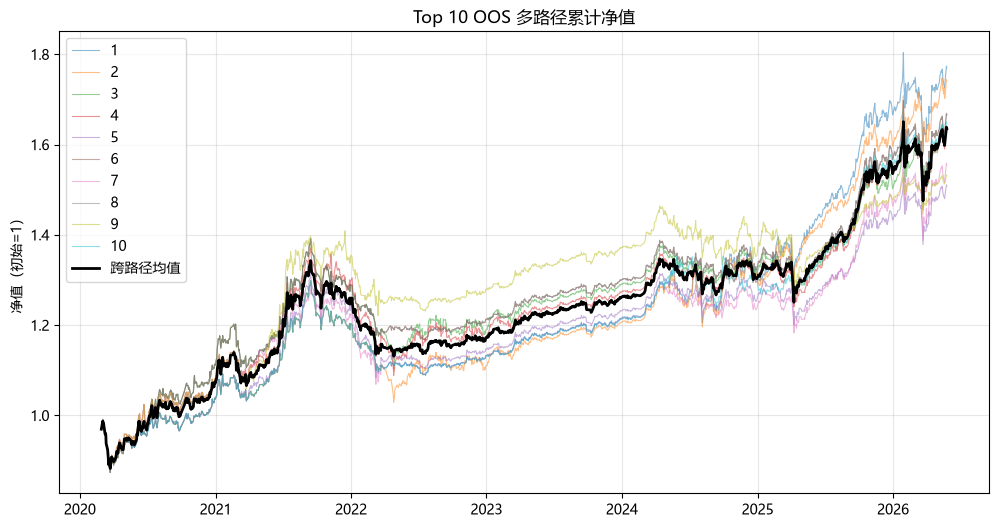

In [16]:
top_k_mpts = Population([mpt for mpt in eval_['mpts'].values()])
plot_paths_curve(top_k_mpts, title='Top 10 OOS 多路径累计净值', labels=[k for k in eval_['mpts'].keys()])

### Ensemble

In [17]:
from wf_topk_ensemble import topk_ensemble_eval

In [19]:
ens = topk_ensemble_eval(X, fold_real, k=10) 

Fold 0: 候选=10 | top1资产=5 | 融合池=7（重叠=5）| top1_test=0.3277 | ens_test=1.2153
Fold 1: 候选=10 | top1资产=4 | 融合池=10（重叠=4）| top1_test=0.6765 | ens_test=0.5548
Fold 2: 候选=10 | top1资产=3 | 融合池=5（重叠=3）| top1_test=1.5656 | ens_test=0.8883
Fold 3: 候选=10 | top1资产=3 | 融合池=4（重叠=3）| top1_test=2.8774 | ens_test=2.2321
Fold 4: 候选=10 | top1资产=4 | 融合池=10（重叠=4）| top1_test=0.5996 | ens_test=0.3610
Fold 5: 候选=10 | top1资产=3 | 融合池=11（重叠=3）| top1_test=1.8685 | ens_test=1.6779
完整 OOS 路径: 6 折拼接, 共 1512 天


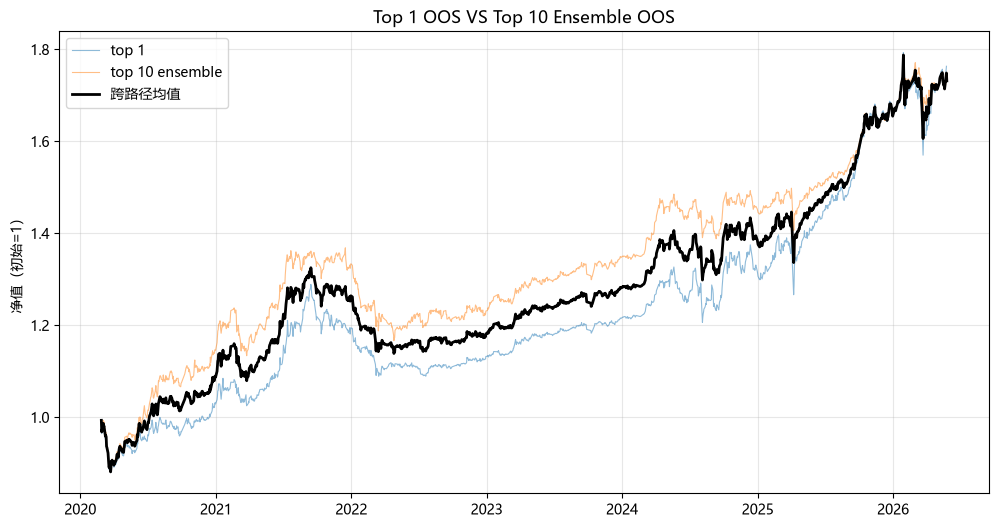

In [20]:
ensemble_mpt = Population([ens['paths']['top1'], ens['paths']['ensemble']])
plot_paths_curve(ensemble_mpt, title='Top 1 OOS VS Top 10 Ensemble OOS', labels=['top 1','top 10 ensemble'])

In [26]:
log_print(ens['paths']['ensemble'].summary(),section='Top 10 Ensemble OSS Summary',echo=False)

### Step 4｜单参数敏感性曲线
- 每折只动目标参数、其余保持生产值（fitness 固定 top1）；`frac=0` 档即生产值本身（锚点）。
- 默认覆盖**全部数值参数含 `train_size`**（它是搜索维度之一，扰动后评估即用扰动后的拟合窗口长度）。
- 读图：参数高原 = ±30% 内绩效平缓；孤峰 = 仅生产值附近突出（与 IS 侧 gap2top1 互证）。
- 只评估单折 OOS → 无 CPCV 展开，成本低，可全参数全档位跑。

In [ ]:
curves = sensitivity_curves(X, fold_results, reduce_test=False)             # 默认 ±10/20/30% 六档 × 全部数值参数
c = curves[curves["param"] == "extremes__k"]
ax = c.pivot_table(index="frac", columns="fold",
                   values="annualized_sharpe_ratio").plot(marker="o")

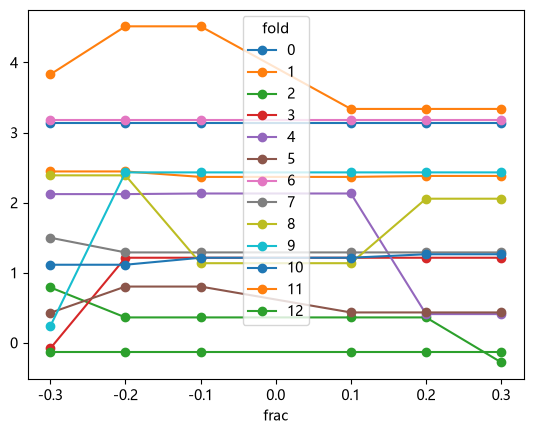

In [17]:
plt.show()

### Step 5｜双参数联合热力图（checklist 4.2）

- 返回 `{fold: DataFrame(index=frac_a, columns=frac_b), "mean": 跨折逐格平均}`。
- 读图：各档平缓 → 联合高原（稳健）；仅 (0,0) 突出 → 联合孤峰（脆弱）；
  对角陡峭 → 两参数互补/冲突（交互项存在）。

Fold 0: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 1: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 2: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 3: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 4: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 5: extremes__k×correlate__threshold 热力图 (5×5) 完成


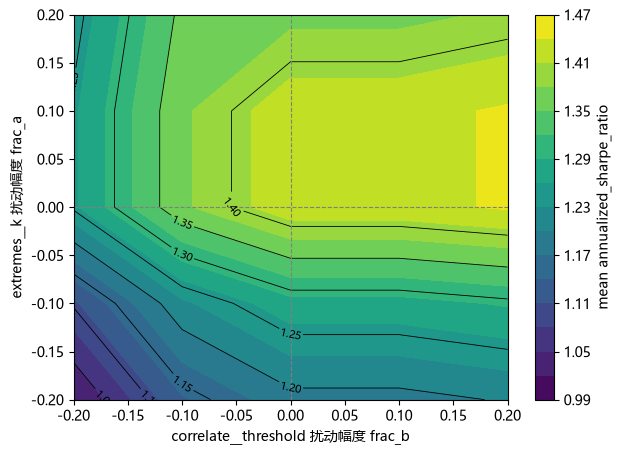

In [27]:
import numpy as np
import matplotlib.pyplot as plt

grids = sensitivity_heatmap(X, fold_results, param_a="extremes__k",
                            param_b="correlate__threshold",
                            reduce_test=False)
mean = grids["mean"]                          # 行=frac_a, 列=frac_b, 值=跨折平均ASR
Xg, Yg = np.meshgrid(mean.columns, mean.index)   # x=frac_b, y=frac_a，与 values[i,j] 对齐
fig, ax = plt.subplots(figsize=(7, 5))
cf = ax.contourf(Xg, Yg, mean.values, levels=15, cmap="viridis")   # 彩色填充
cs = ax.contour(Xg, Yg, mean.values, levels=8, colors="k", linewidths=0.6)  # 等值线
ax.clabel(cs, inline=True, fontsize=8)        # 标数值
ax.axhline(0, color="gray", lw=0.8, ls="--")  # 生产值锚点十字线（0,0 = 未扰动）
ax.axvline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("correlate__threshold 扰动幅度 frac_b")
ax.set_ylabel("extremes__k 扰动幅度 frac_a")
fig.colorbar(cf, label="mean annualized_sharpe_ratio")
plt.show()

### Step 6｜消融实验

- 臂：`full`（基准）/ `no_extremes` / `no_nondomin` / `no_correlate` / `no_extremes_correlate`。
- 每臂 = 固定每折最优参数 × 剔除对应管线步骤 × CPCV 多路径压测（同窗同口径对比）。
- 判读：全臂样本路径数一致（每折 = `n_test_folds` 组合路径），绩效差距即模块边际贡献；
  某模块剔除后绩效**不降反升** → 该模块负贡献，考虑剔除后重搜（会作废旧 OOS）。

In [28]:
frames, summary = ablate(X, fold_results)                # arms=None = 全部 5 臂
summary

,说明,折数,天数,annualized_mean,annualized_sharpe_ratio,max_drawdown,skew,kurtosis
臂,,,,,,,,
full,全管线（基准）,6,1512,0.147428,1.409906,0.117127,-0.706746,12.263907
no_extremes,无峰度预筛（剔除 extremes 步骤）,6,1512,0.072016,1.252114,0.070319,-0.475426,16.276420
no_nondomin,无非支配筛选（剔除 nondomin 步骤）,6,1512,0.134805,1.076243,0.216079,-0.051876,6.815464
no_correlate,无去相关（剔除 correlate 步骤）,6,1512,0.075156,0.522658,0.349710,-0.370876,7.840212
no_extremes_correlate,剔除 extremes + correlate,6,1512,0.078427,0.660672,0.263099,-0.268241,13.381875


In [29]:
log_result(summary.to_string(), section="消融实验")

### Step 7｜参数扰动蒙特卡洛 + 判定

In [ ]:
out = perturbation_mc(X, fold_results, fitness_topk=5)                   # R=None → ceil(500 / 折数)，总样本 ≥ 500

In [ ]:
out['verdict']

In [ ]:
out['fold_summary']

In [30]:
oos_pop = Population([fold['test'] for fold in fold_results])
oos_pop.plot_cumulative_returns()

In [31]:
oos_mpt = MultiPeriodPortfolio([fold['test'] for fold in fold_results],compounded=True)
oos_mpt.plot_cumulative_returns()

#### 路径采样

In [32]:
fold_paths = adaptive_multi_paths(X, fold_results, 
                                 test_size=search_params['test_size'], 
                                 train_size=search_params['train_size'],
                                 n_test_folds=search_params['n_test_folds'], n_jobs=8)

Fold 0: paths=3 | window=504 | inner_folds=4 | test_days=252
Fold 1: paths=3 | window=504 | inner_folds=4 | test_days=252
Fold 2: paths=5 | window=756 | inner_folds=6 | test_days=252
Fold 3: paths=3 | window=504 | inner_folds=4 | test_days=252
Fold 4: paths=3 | window=504 | inner_folds=4 | test_days=252
Fold 5: paths=7 | window=1008 | inner_folds=8 | test_days=252


In [33]:
oos_blocks = build_test_parts(fold_paths, n_test_folds=search_params['n_test_folds'])
oos_paths = discrete_lhs_safe(oos_blocks, n_samples=1000, seed=42)
oos_mpts = Population([MultiPeriodPortfolio(path ,compounded=False) for path in oos_paths])

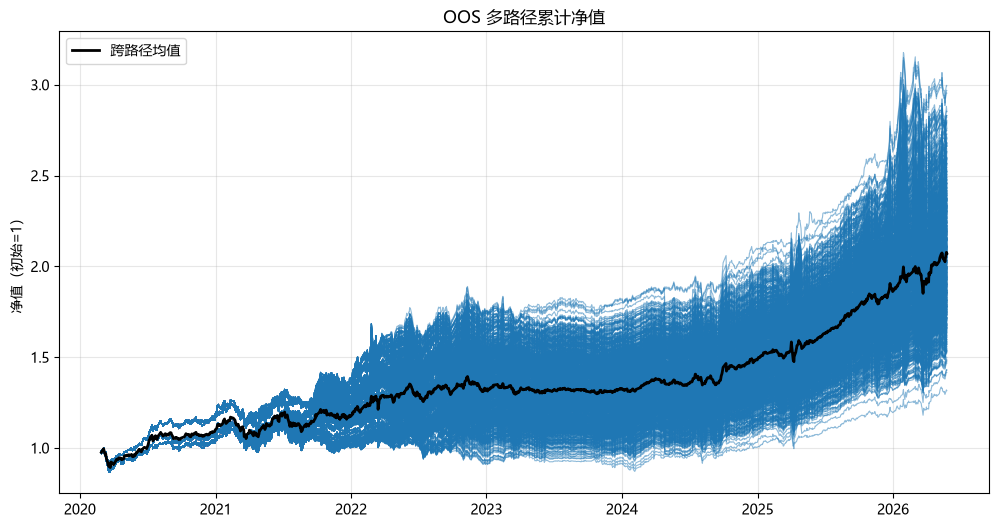

In [34]:
plot_paths_curve(oos_mpts)

In [35]:
log_print(oos_mpt.summary(),section='OSS Summary',echo=False)

### OOS诊断：
- Annualized Mean 分布
- PSR诊断
- 基准联动
- 换手频率

LHS多路径分布(1000条): 均值 0.1269 | 中位 0.1269 | 5% 0.0882 | 95% 0.1663
WF真实路径: 0.0769 | 分布中 -2.10σ | 分位 1.2%


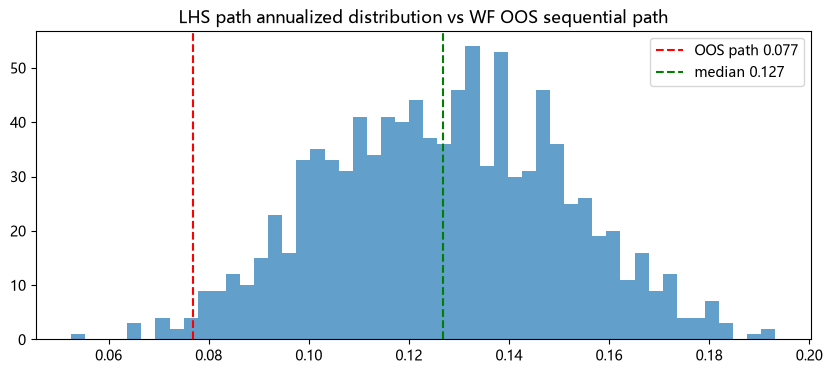

In [36]:
# 年化分布
path_anns = np.array([oos_mpt.annualized_mean for oos_mpt in oos_mpts])

oos_ann = oos_mpt.annualized_mean

report_ann_distribution(path_anns, oos_ann)

In [37]:
diagnose_result = diagnose_oos_lhs(lhs_paths=oos_paths)
del diagnose_result['mc_sharpes']
del diagnose_result['mc_mdds']
del diagnose_result['mc_psrs']
log_print(diagnose_result, section='OOS PSR Diagnose',echo=False)

[Info] 1000 LHS paths | OOS 1512 days

          纯 OOS 策略诊断报告 (LHS)
  ✅ P(SR<=0)              : 0.00%
  ✅ Sharpe 90% CI         : [0.598, 1.158]
  ✅ MDD median / worst-5%  : 14.18% / 18.34%
------------------------------------------------------------
  ⚠️ SR_obs (median)       : 0.9049
  ⚠️ PSR(0) median / 5%    : 100.00% / 100.00%


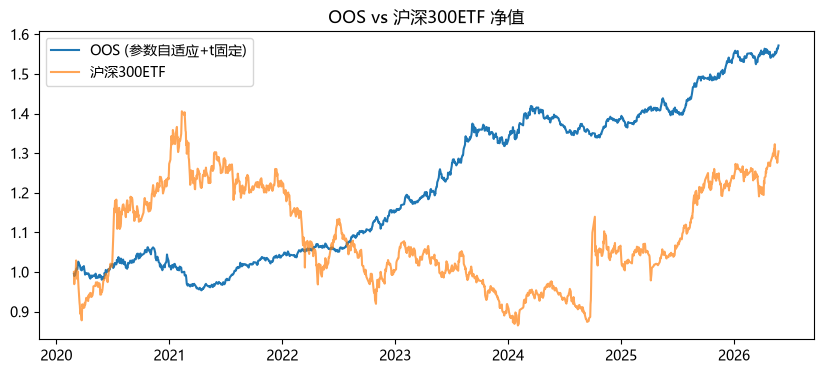

In [38]:
plot_oos_vs_bench(oos_mpt, bench_ret)

In [39]:

df_ex = excess_vs_bench(oos_mpts, bench_ret)
log_result(df_ex.describe(percentiles=[0.05, 0.5, 0.95]).loc[["5%", "50%", "95%", "mean"]].round(4),
           section="OOS vs 沪深300 相对收益分布")

      ann_excess  arith_excess      IR  winrate
5%        0.0400        0.0293  0.1929   0.5192
50%       0.0770        0.0680  0.4487   0.5298
95%       0.1146        0.1074  0.6623   0.5417
mean      0.0770        0.0680  0.4388   0.5301


### 模拟+双向参数迁移验证
（Bidirectional Parameter Transfer Validation）
```python
# 1）可选传基准供画图：simulate_sl(..., bench=bench_ret)，结果在 res["bench"]
cmp_tbl = summarize_sl(res, base)
# 2) 落盘（与既有 log_result 体系一致）
log_result(cmp_tbl,         section="SL模拟 vs 无止损基线")
log_result(res["epochs"],   section="SL 模拟 epoch 明细")
log_result(res["triggers"], section="SL 触发明细")
```

In [28]:
from sl_simulation import load_sl_config, simulate_sl, summarize_sl

In [29]:
cfg  = load_sl_config()
cfg['space'] = search_space
cfg['search_kwargs'] = search_params

In [ ]:
oos = simulate_sl(X, folds=fold_real, cfg=cfg, conditions=[])

In [ ]:
fake = simulate_sl(X, folds=fold_fake, cfg=cfg, conditions=[])

Epoch 0: 2020-02-27 -> 2021-03-10 (252d, expired) | src=fold_reuse | ASR=1.414 | 累计=17.83%
Epoch 1: 2021-03-11 -> 2022-03-23 (252d, expired) | src=fold_reuse | ASR=1.162 | 累计=11.00%
Epoch 2: 2022-03-24 -> 2023-04-06 (252d, expired) | src=fold_reuse | ASR=0.931 | 累计=9.11%
Epoch 3: 2023-04-07 -> 2024-04-22 (252d, expired) | src=fold_reuse | ASR=1.522 | 累计=7.96%
Epoch 4: 2024-04-23 -> 2025-05-09 (252d, expired) | src=fold_reuse | ASR=0.932 | 累计=11.37%
Epoch 5: 2025-05-12 -> 2026-05-25 (252d, expired) | src=fold_reuse | ASR=2.618 | 累计=35.96%
决策日 2026-05-25: fresh CPCV 重搜 | 外层窗口 1008 天 | test_size=252 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 6: 2026-05-26 -> 2026-09-18 (83d, end_of_data) | src=fresh | ASR=0.949 | 累计=5.35%


In [ ]:
ctrl  = simulate_sl(X, folds=fold_ctrl, cfg=cfg, conditions=[])

Epoch 0: 2020-02-27 -> 2021-03-10 (252d, expired) | src=fold_reuse | ASR=-0.461 | 累计=-3.52%
Epoch 1: 2021-03-11 -> 2022-03-23 (252d, expired) | src=fold_reuse | ASR=2.438 | 累计=9.63%
Epoch 2: 2022-03-24 -> 2023-04-06 (252d, expired) | src=fold_reuse | ASR=2.906 | 累计=13.07%
Epoch 3: 2023-04-07 -> 2024-04-22 (252d, expired) | src=fold_reuse | ASR=2.319 | 累计=17.81%
Epoch 4: 2024-04-23 -> 2025-05-09 (252d, expired) | src=fold_reuse | ASR=0.124 | 累计=0.41%
Epoch 5: 2025-05-12 -> 2026-05-25 (252d, expired) | src=fold_reuse | ASR=2.143 | 累计=11.09%
决策日 2026-05-25: fresh CPCV 重搜 | 外层窗口 1008 天 | test_size=252 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 6: 2026-05-26 -> 2026-09-18 (83d, end_of_data) | src=fresh | ASR=-0.427 | 累计=-0.95%


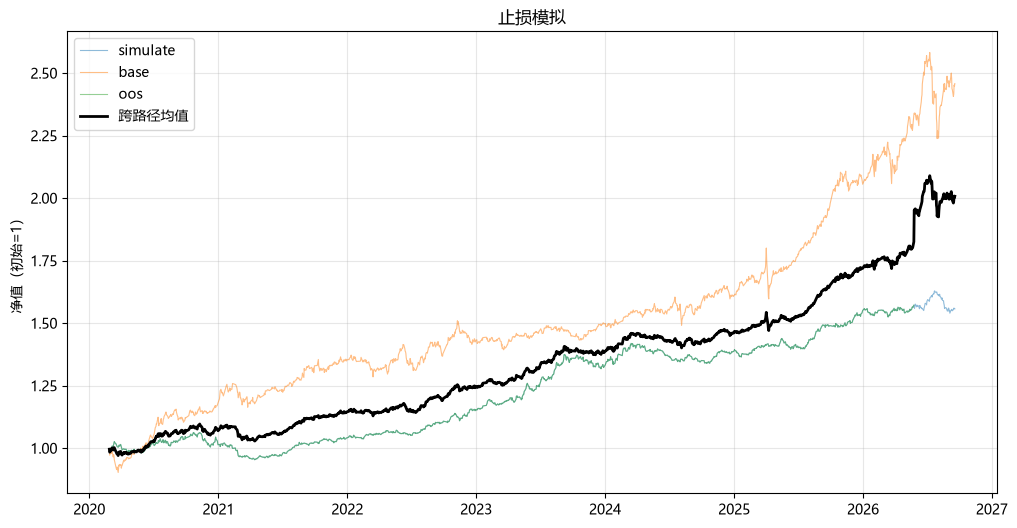

In [44]:
sl_mpts = Population([res['mpt'], base['mpt'], oos_mpt])
plot_paths_curve(sl_mpts, title='止损模拟', labels=['simulate','base', 'oos'])

In [ ]:
for pf in res['legs']:
    print(pf.assets)

### Fresh CPCV

In [ ]:
cfg = load_sl_config(); cfg['space'] = search_space; cfg['search_kwargs'] = search_params
X_cut = X.tail(search_params['train_size'] + 1)      # 搜索窗口 + 1 天建仓日
final = simulate_sl(X_cut, cfg=cfg, conditions=[])   # 不传 folds → 全程 fresh；conditions=[] 纯搜索
# 参数记录: final['searches']  |  建仓头寸: final['legs'][0].weights / .assets

决策日 2026-09-17: fresh CPCV 重搜 | 外层窗口 1008 天 | test_size=252 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 0: 2026-09-18 -> 2026-09-18 (1d, end_of_data) | src=fresh | ASR=nan | 累计=0.52%


In [81]:
final['mpt'].assets

[array(['161115.SZ', '161127.SZ', '501046.SH', '511270.SH', '515150.SH',
        '516310.SH'], dtype=object)]

In [ ]:
[array(['160611.SZ', '163409.SZ', '501046.SH', '511270.SH', '513000.SH',
        '515020.SH', '560780.SH'], dtype=object)]
[array(['161115.SZ', '161127.SZ', '161128.SZ', '501046.SH', '501087.SH',
        '511270.SH', '515150.SH', '516310.SH', '560780.SH'], dtype=object)]

In [46]:
X_cut = X_ctrl.tail(search_params['train_size'] + 1)      # 搜索窗口 + 1 天建仓日
final = simulate_sl(X_cut, cfg=cfg, conditions=[])
final['mpt'].assets

决策日 2026-09-17: fresh CPCV 重搜 | 外层窗口 1008 天 | test_size=252 | n_trials=2000


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 0: 2026-09-18 -> 2026-09-18 (1d, end_of_data) | src=fresh | ASR=nan | 累计=0.48%


[array(['159207.SZ', '160643.SZ', '160722.SZ', '161039.SZ', '161119.SZ',
        '163907.SZ', '164210.SZ', '164808.SZ', '166009.SZ', '168105.SZ',
        '169106.SZ', '180701.SZ', '501038.SH', '501202.SH', '508011.SH',
        '508033.SH', '508098.SH', '511520.SH', '515450.SH', '518860.SH',
        '560880.SH'], dtype=object)]

In [52]:
# 单轮（实盘前最后一次搜索）场景：
rec   = next(iter(final["searches"].values()))
study = rec["study"]          # ← optuna Study 对象，trial 级全历史：trial.params / trial.value / trial.state

# 直接喂给体系里消费 study 的函数：
from cpcv_analysis import empirical_deflate, top_trials
d     = empirical_deflate(study)            # margin / max_p95 / n_trials_total 全套（从 study 现算，无重算搜索）
cands = top_trials(study.trials, k=10)      # Top-K 候选

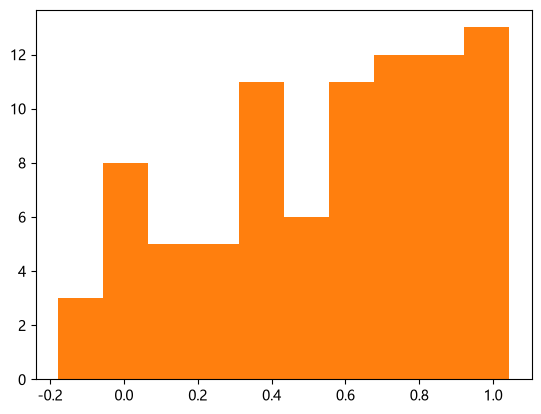

In [54]:
plt.hist(d['scores'])
plt.show()

### 双向参数迁移验证”（Bidirectional Parameter Transfer Validation）